In [1]:
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import numpy as np
import json

from torch.utils.data import DataLoader

from os import listdir
from os.path import isfile, join

import VAE


In [2]:
device = torch.device("mps")

In [3]:
latentDim =32
Model = VAE.VAE(latentDim,device).to(device)

In [30]:
Checkpoint = torch.load("Checkpoint_Meta.pt",map_location=torch.device('mps'))
print(Checkpoint)

{'Epoch': 999, 'Model': OrderedDict({'Encoder.M1.0.weight': tensor([[[[ 2.8403e-02,  1.0499e-01,  7.6828e-02,  2.8034e-02,  4.5408e-02],
          [ 1.0817e-02,  2.5498e-02,  2.6156e-02, -6.3738e-03, -4.1315e-02],
          [ 4.3318e-02,  3.5353e-02,  2.3752e-03, -3.9449e-02, -7.2664e-02],
          [ 2.5546e-02,  3.3716e-02,  1.6212e-02, -8.8239e-03, -7.2077e-02],
          [-2.3979e-04,  1.5606e-02, -4.3135e-02, -8.1606e-02, -1.7166e-01]],

         [[-5.2496e-02,  3.1746e-02,  1.9026e-02,  4.8640e-02,  1.3722e-01],
          [ 7.4739e-03,  3.3866e-02,  5.9352e-03,  1.6093e-02,  5.1774e-02],
          [-1.9470e-02,  4.4430e-02,  9.9687e-03, -3.6748e-03,  2.0662e-02],
          [ 3.0395e-02,  5.1231e-02,  1.5643e-02,  1.6391e-02, -2.3974e-02],
          [ 1.7242e-02, -1.4992e-03, -9.7920e-03, -4.5000e-02, -8.0036e-02]],

         [[-7.1526e-02,  3.5567e-02,  8.4151e-02,  9.7387e-02,  3.9323e-01],
          [-1.1411e-02, -1.1580e-02, -2.1705e-02,  4.5607e-02,  1.9141e-01],
          [-

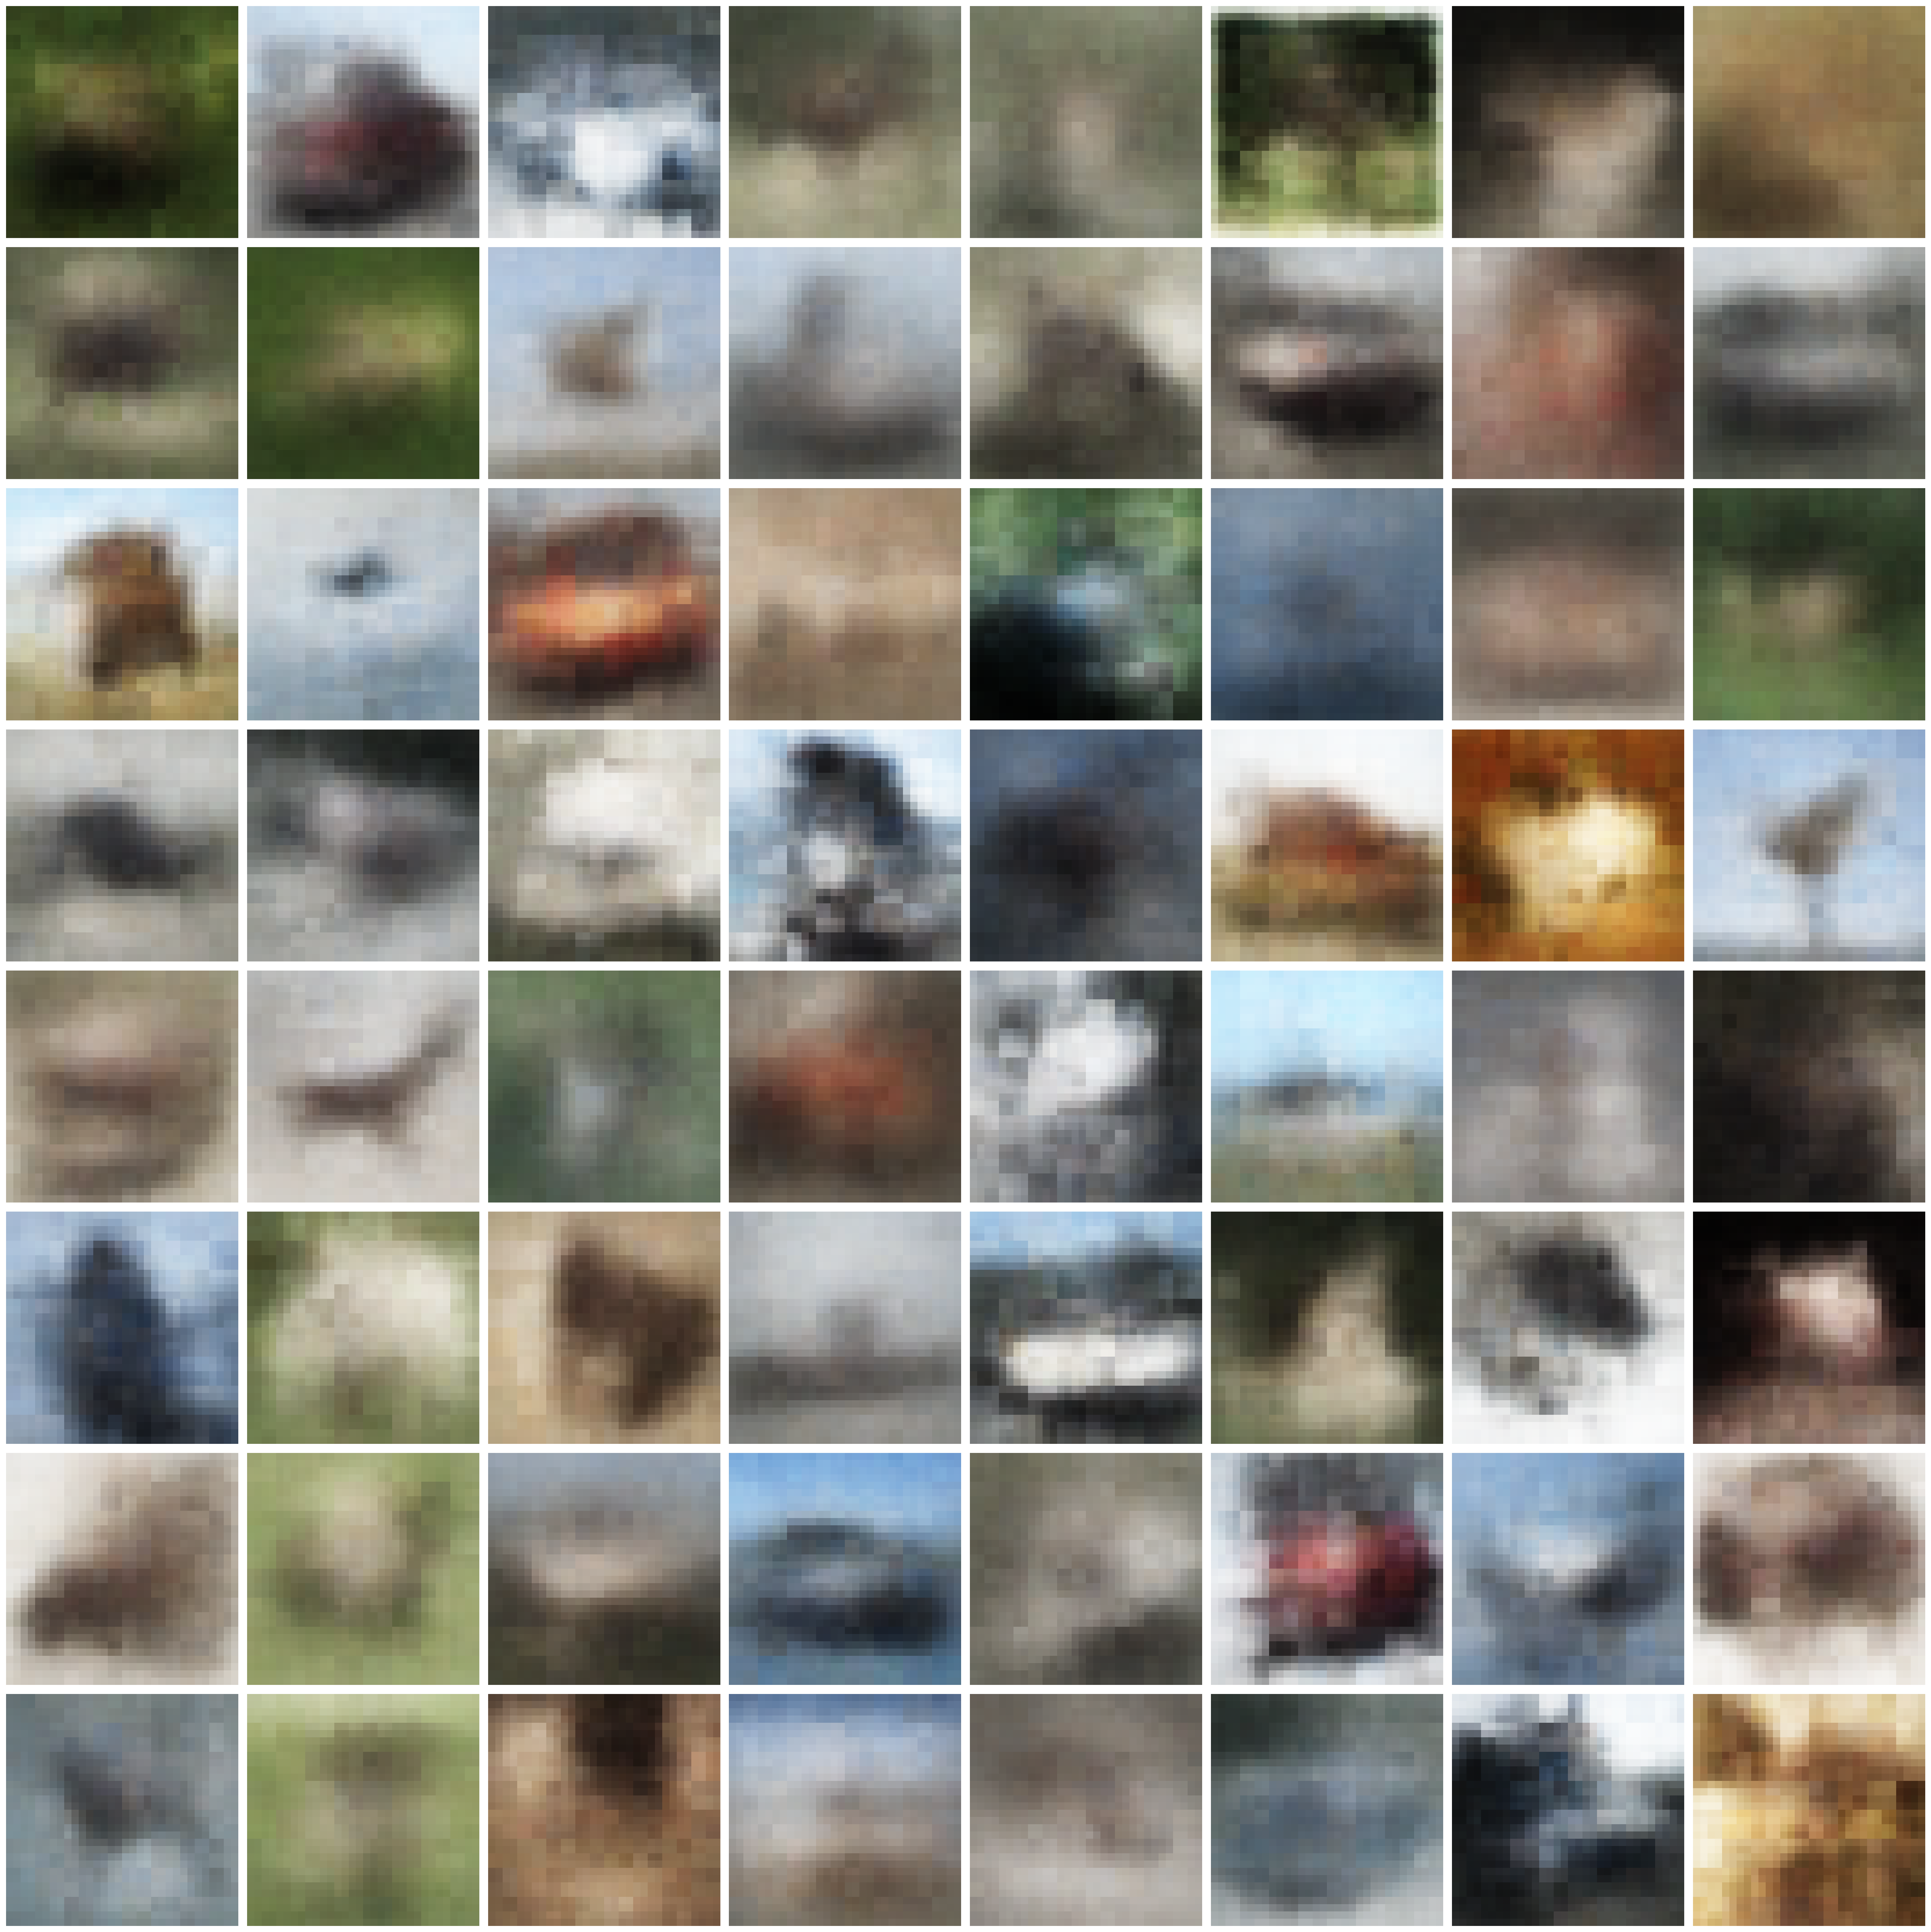

In [29]:
Z = torch.randn((64, latentDim), device=device)
load = True

Model.load_state_dict(Checkpoint["Model"])
    
with torch.no_grad():
    fakes = Model.Decoder(Z)

fig, axes = plt.subplots(8, 8, figsize=(32, 32), dpi=200)
for i in range(64):
    row = i // 8
    col = i % 8
    img = fakes[i].detach().cpu()
    img = img.permute(1, 2, 0)
    img = (img + 1) / 2
    img = img.clamp(0, 1).numpy()
    axes[row, col].imshow(img)
    axes[row, col].axis("off")
plt.tight_layout()
plt.show()

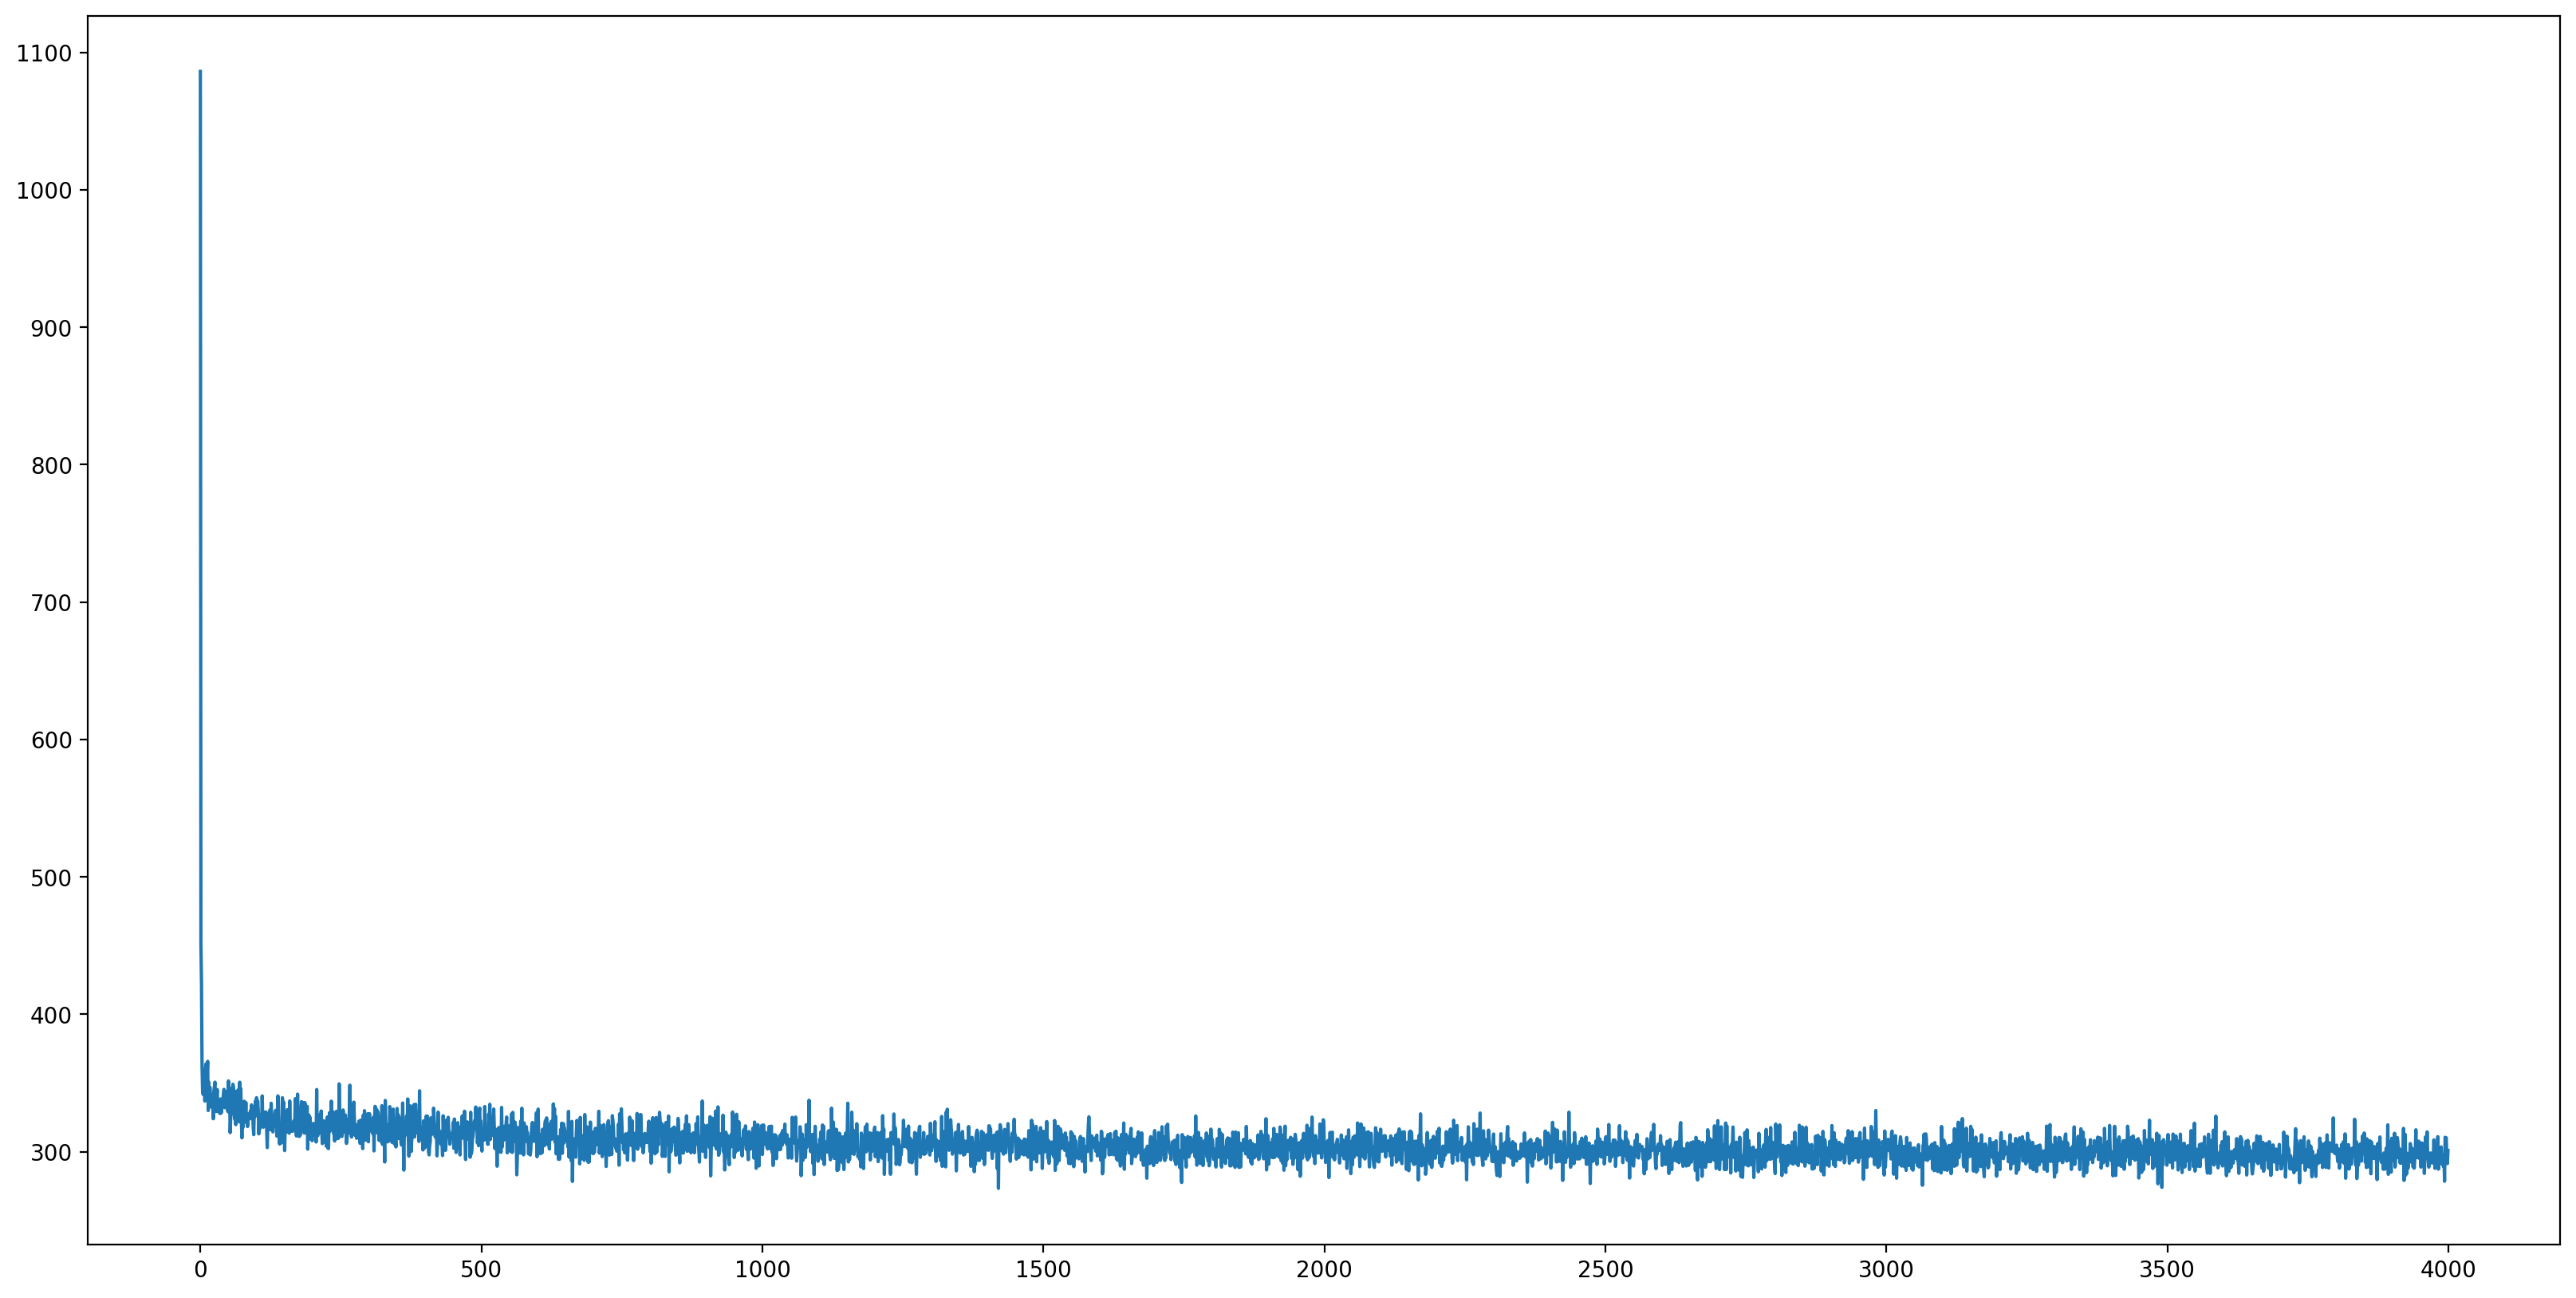

In [31]:
plt.figure(figsize=(20, 10), dpi=200)
LossesG = [i.to(torch.device("cpu")) for i in Checkpoint["Losses"]]
plt.plot(LossesG)


In [34]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

class CIFAR_DataLoader(torch.utils.data.Dataset):

    def __init__(self,dir,device):
        self.files = [f for f in listdir(dir) if isfile(join(dir, f))]
        self.Data = torch.tensor([])
        self.Labels = torch.tensor([])
        self.testData =torch.tensor([])
        self.testLabel =torch.tensor([])
        for file in self.files:
            #print(file)
            if "data" in file:
                tempData = unpickle(f"{dir}/{file}")

                self.Labels = torch.cat((self.Labels,torch.tensor(tempData[b"labels"])),0)

                self.Data = torch.cat((self.Data,torch.tensor(tempData[b"data"])),0)
    
            elif "test" in file:
                pass
        #print(self.Data.shape)
        
        self.Data = self.Data.reshape(self.Data.shape[0],3,32,32)
        self.Data = self.Data.to(torch.float32)
        #print(self.Data.shape)
        self.Data = (self.Data / 127.5) - 1
    def __len__(self):
        return self.Labels.shape[0]
        
    def __getitem__(self,index):
        return self.Data[index] , self.Labels[index]



In [46]:

batch_size = 64
Data = CIFAR_DataLoader("cifar-10-batches-py",device)
train_dataloader = DataLoader(Data, batch_size=batch_size, shuffle=True)


/var/folders/_8/5q7jkgdx3fx_kvr5tnf9v5s80000gn/T/ipykernel_26254/298449367.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')
